# Pedestrian Crash Severity Prediction in London
## Integrating Road Network Topology Features with Machine Learning

**Course:** CASA0006 / [Your Course Code]  
**Student:** [Your Name]  
**Date:** April 2026

---

## Abstract

> This notebook investigates pedestrian crash severity prediction in London using five years of STATS19 data (2019–2023). We address two limitations common in the literature: (1) the tendency to merge Fatal and Serious injury classes, which obscures policy-relevant distinctions; and (2) the neglect of road network topology as a predictor of crash outcomes. We introduce edge betweenness centrality as a novel feature representing road segment traffic flow potential, and systematically compare prediction performance with and without this network feature. Given the severe class imbalance in the dataset (Fatal: 1.2%, Serious: 25.7%, Slight: 73.4%), we employ class weighting, joint threshold optimisation, and evaluate models using G-mean and macro F1-score rather than accuracy. Results show that [to be completed].

---

## Table of Contents

1. [Research Context and Questions](#1-research-context-and-questions)
2. [Data Collection and Preparation](#2-data-collection-and-preparation)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Network Feature Engineering](#4-network-feature-engineering)
5. [Methodology](#5-methodology)
6. [Series A: Baseline Models (STATS19 Features Only)](#6-series-a-baseline-models)
7. [Series B: Enhanced Models (+ Network Features)](#7-series-b-enhanced-models)
8. [Results and Comparison](#8-results-and-comparison)
9. [Interpretability: SHAP Analysis](#9-interpretability-shap-analysis)
10. [Discussion](#10-discussion)
11. [Conclusion](#11-conclusion)

---
## 2. Data Collection and Preparation
*(Marking criterion: Data collection, handling, and presentation — 15%)*

### 2.1 Data Sources

| Dataset | Source | Coverage | Variables Used |
|---------|--------|----------|----------------|
| STATS19 Collisions | DfT Open Data | 2019–2023 | severity, speed, weather, light, road type, junction |
| STATS19 Casualties | DfT Open Data | 2019–2023 | casualty_severity, vehicle_type, age_of_vehicle |
| STATS19 Vehicles | DfT Open Data | 2019–2023 | ---------, ---------, --------- |
| OS Road Network | OSMnx (OpenStreetMap) | Greater London | geometry, edge betweenness centrality |

### 2.2 Data Loading

In [1]:
# ── Core Libraries ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Spatial Libraries ─────────────────────────────────────────────────────────
import osmnx as ox
import networkx as nx
import igraph as ig
from shapely.geometry import Point

# ── ML Libraries ──────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from imblearn.metrics import geometric_mean_score
import shap

# ── Plot Settings ─────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
COLORS = {'Fatal': '#d62728', 'Serious': '#ff7f0e', 'Slight': '#2ca02c'}

print("Libraries loaded successfully")

Libraries loaded successfully


In [18]:
# ── Load STATS19 Data ─────────────────────────────────────────────────────────

# Load London LSOA (Lower Layer Super Output Area) boundaries to define the geographic study area
lon_lsoa = gpd.read_file('../Data/statistical-gis-boundaries-london/ESRI/LSOA_2011_London_gen_MHW.shp')

# Load raw collision data (contains coordinates and environmental factors)
collision = pd.read_csv('../Data/dft-road-casualty-statistics-collision-last-5-years.csv')

# Perform an inner merge to keep only accidents that occurred within London LSOA boundaries
lon_collision_5Y = lon_lsoa.merge(collision, left_on='LSOA11CD', right_on='lsoa_of_accident_location', how='inner')

# Data Deduplication: STATS19 records can sometimes overlap or be recorded multiple times
lon_collision_5Y = lon_collision_5Y.drop_duplicates(subset=["collision_ref_no"], keep='first')

# Load casualty data (contains details about people injured)
casualty = pd.read_csv('../Data/dft-road-casualty-statistics-casualty-last-5-years.csv')

# Filter for Pedestrians only (casualty_type == 0 is the code for pedestrians in STATS19)
pedestrain_casualty = casualty[casualty["casualty_type"] == 0]

# One accident can have multiple casualties. We prioritize the most severe injury 
# (Note: In STATS19, 1 = Fatal, 2 = Serious, 3 = Slight, so ascending order captures highest severity)
pedestrain_most_severe = pedestrain_casualty.sort_values(
    by=['collision_index', 'casualty_severity'], 
    ascending=[True, True]
).drop_duplicates(subset=['collision_index'], keep='first')

# Load vehicle data (contains details about engine size, vehicle age, etc.)
vehicle = pd.read_csv('../Data/dft-road-casualty-statistics-vehicle-last-5-years.csv')

# Merge filtered London collisions with the most severe pedestrian casualty records
lon_pedestrain_casualty_collision = pd.merge(pedestrain_most_severe, lon_collision_5Y, on='collision_index', how='inner')

# Join with vehicle data to identify the vehicle involved in the pedestrian hit
lon_pedestrain_collision_5y = pd.merge(lon_pedestrain_casualty_collision, vehicle, on='collision_index', how='left')

# In multi-vehicle accidents, filter for the primary vehicle (reference 1) to simplify the analysis
# to the most likely vehicle that struck the pedestrian.
lon_pedestrain_collision_5y = lon_pedestrain_collision_5y[lon_pedestrain_collision_5y["vehicle_reference_y"] == 1]

# give the table a simple name `df`
df = lon_pedestrain_collision_5y

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['casualty_severity'].value_counts())
print(f"\nMissing values:")

Dataset shape: (19963, 112)

Class distribution:
casualty_severity
3    14614
2     5116
1      233
Name: count, dtype: int64

Missing values:


### 2.3 Data Cleaning and Feature Selection

In [19]:
# ── Missing Value Imputation ───────────────────────────────────────────────────
# STATS19 uses '-1' to represent 'Data missing or out of range'
# Converting to NaN allows for proper imputation or exclusion during machine learning
df.replace(-1, np.nan, inplace=True)

# ── Cyclic Encoding for Hour ───────────────────────────────────────────────────
# extract 'hour' from the 'time' string to create a cyclical numerical feature for the model
time_dt = pd.to_datetime(df['time'], format='%H:%M', errors='coerce')

df['hour_continuous'] = time_dt.dt.hour + time_dt.dt.minute / 60.0

df['hour_sin'] = np.sin(2 * np.pi * df['hour_continuous'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_continuous'] / 24)

# ── Cyclic Collision Monthh ───────────────────────────────────────────────────
dt_series = pd.to_datetime(df['date'], format='%d/%m/%Y', errors='coerce')
month = dt_series.dt.month
df['month_sin'] = np.sin(2 * np.pi * month / 12)
df['month_cos'] = np.cos(2 * np.pi * month / 12)

# Remove original 'time', 'hour', 'date' column to maintain feature matrix integrity
df.drop(columns=['time', 'hour_continuous', 'date'], inplace=True)

# Final Integrity Check: Drop rows missing the Target (severity) or spatial data
# Without coordinates, the record cannot be snapped to the road network later.
df.dropna(subset=['casualty_severity'], inplace=True)
df.dropna(subset=['longitude', 'latitude'], inplace=True)

# ── Feature Selection ─────────────────────────────────────────────────────────
cols_selected = [                               
    # ── Environmental Context ──────────────────────────────────────────
    'speed_limit', 
    'light_conditions', 
    'weather_conditions', 
    'road_surface_conditions',
    'road_type', 
    'junction_detail', 
    'junction_control',
    'urban_or_rural_area',

    # ── Temporal Features (Cyclic & Linear) ────────────────────────────
    'hour_sin', 'hour_cos',           # High-precision time
    'month_sin', 'month_cos',         # Seasonal continuity
    'day_of_week',                    # Social behavior (1-7)
    'collision_year',                           # Yearly trend (Recommended)

    # ── Vehicle Characteristics ────────────────────────────────────────
    'vehicle_type', 
    'engine_capacity_cc', 
    'age_of_vehicle', 
    'propulsion_code',

    # ── Human Factors  ──────────────────────────────────────────────────
    'age_of_driver', 
    'sex_of_driver',
    
    # ── Casuality Factors  ───────────────────────────────────────────────
    'sex_of_casualty', 'age_of_casualty'   
]
X = df[cols_selected].copy()
y = df['casualty_severity'].copy()


print(f"Final feature matrix shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")
print(df.notnull().sum())

Final feature matrix shape: (19963, 22)
Features: ['speed_limit', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'road_type', 'junction_detail', 'junction_control', 'urban_or_rural_area', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_week', 'collision_year', 'vehicle_type', 'engine_capacity_cc', 'age_of_vehicle', 'propulsion_code', 'age_of_driver', 'sex_of_driver', 'sex_of_casualty', 'age_of_casualty']
collision_index            19963
collision_year_x           19963
collision_ref_no_x         19963
vehicle_reference_x        19963
casualty_reference         19963
                           ...  
driver_distance_banding     2352
hour_sin                   19963
hour_cos                   19963
month_sin                  19963
month_cos                  19963
Length: 114, dtype: int64


### 2.4 Train / Validation / Test Split

We use a stratified 60/20/20 split. The validation set is held out for threshold tuning only — it is never used for model training. The test set is touched only once for final evaluation.

In [20]:
# ── Stratified Split ──────────────────────────────────────────────────────────
# stratify=y ensures Fatal/Serious/Slight proportions are preserved in each split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=63, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=63, stratify=y_temp
)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"\nClass distribution in test set:")
print(y_test.value_counts().sort_index())

Train: 11,977 | Val: 3,993 | Test: 3,993

Class distribution in test set:
casualty_severity
1      47
2    1023
3    2923
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis
*(Marking criterion: Correctness, depth, and scope — 35% | Visualisation — 10%)*

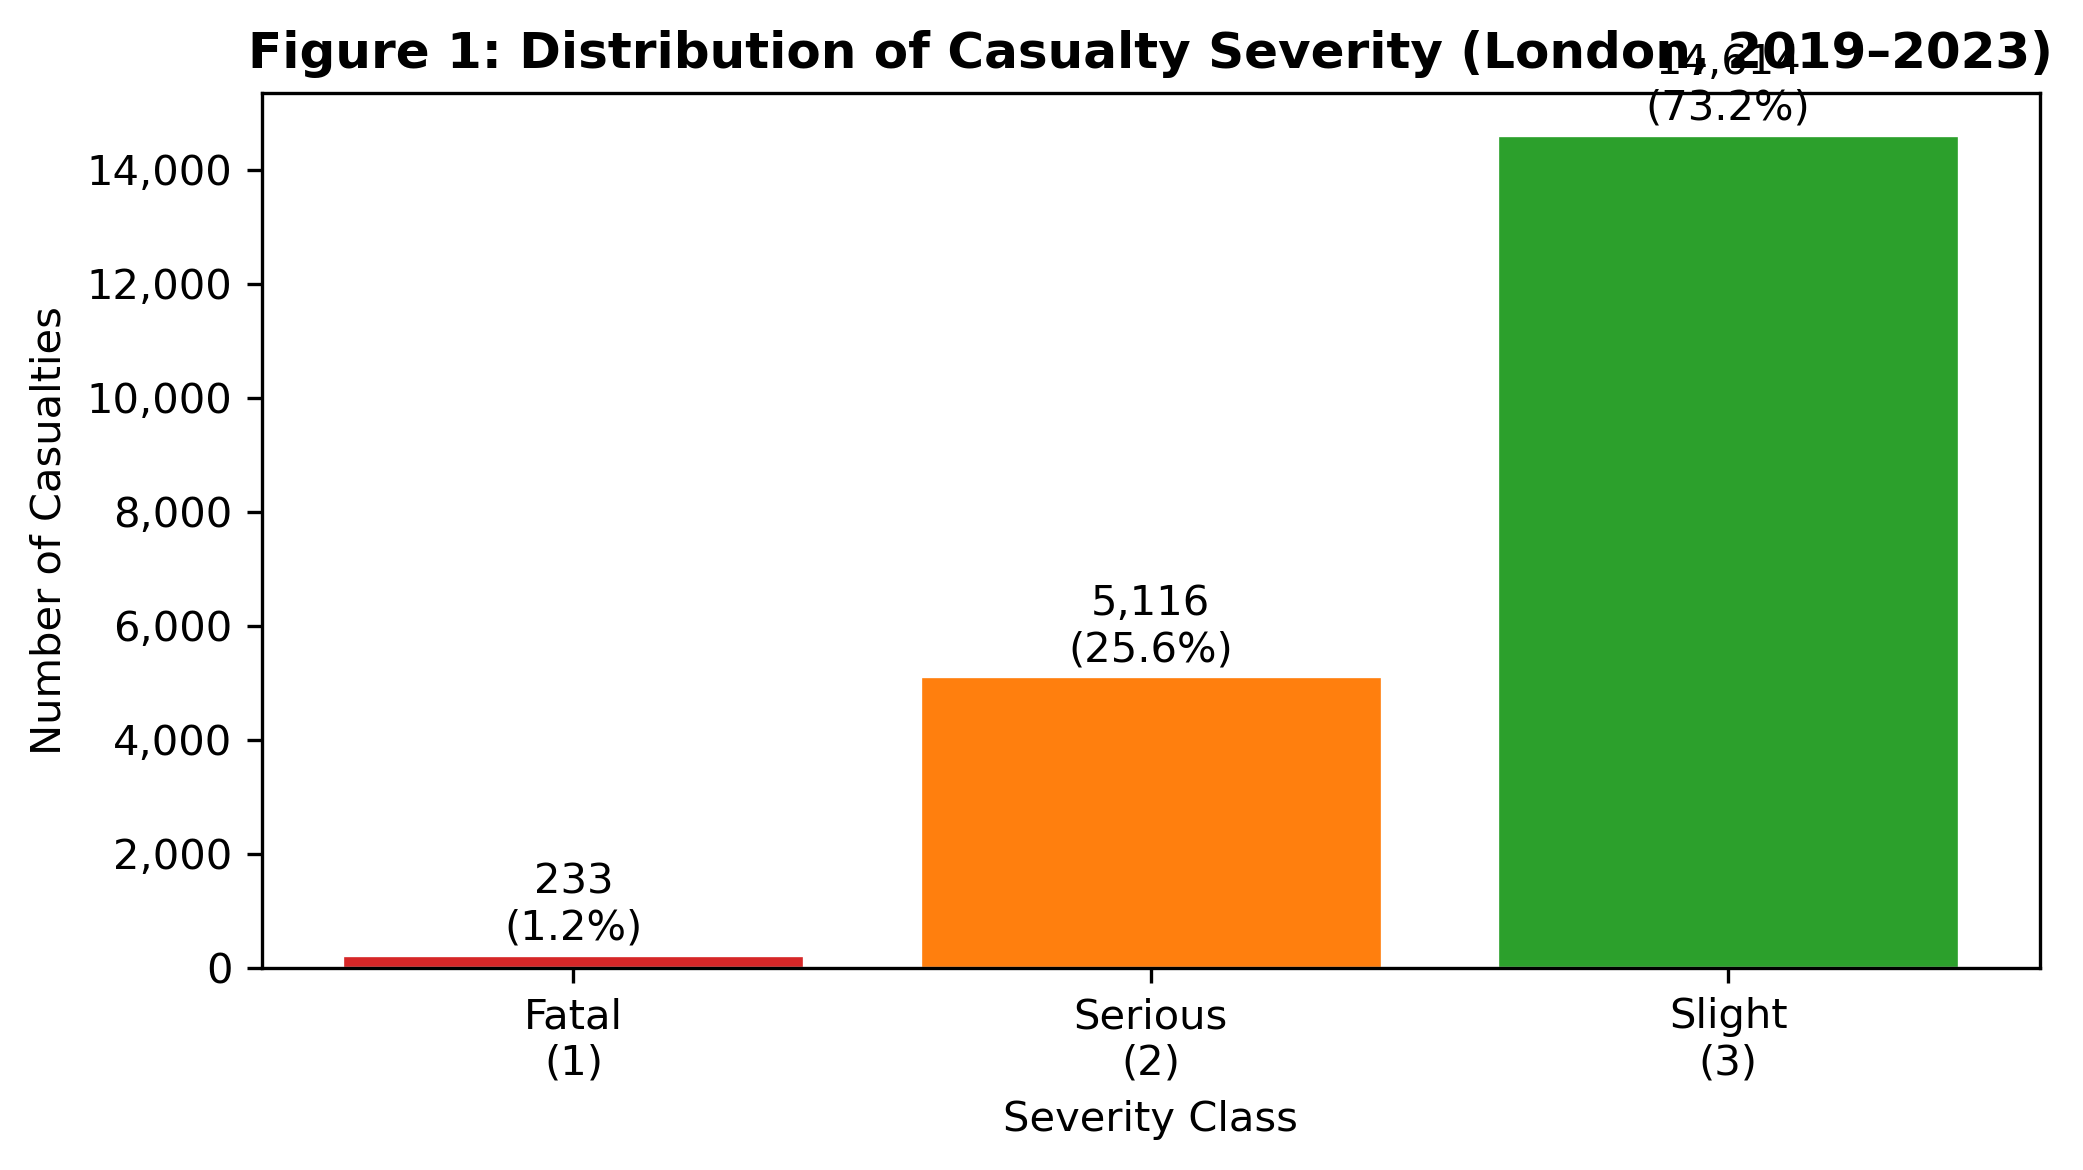


Class imbalance ratios:
  Slight:Fatal   = 63:1
  Slight:Serious = 2.9:1


In [5]:
# ── Figure 1: Class Distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

counts = y.value_counts().sort_index()
bars = ax.bar(
    ['Fatal\n(1)', 'Serious\n(2)', 'Slight\n(3)'],
    counts.values,
    color=[COLORS['Fatal'], COLORS['Serious'], COLORS['Slight']],
    edgecolor='white', linewidth=0.8
)

for bar, count in zip(bars, counts.values):
    pct = count / len(y) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_title('Figure 1: Distribution of Casualty Severity (London, 2019–2023)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Casualties')
ax.set_xlabel('Severity Class')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../figure/fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClass imbalance ratios:")
print(f"  Slight:Fatal   = {counts[3]/counts[1]:.0f}:1")
print(f"  Slight:Serious = {counts[3]/counts[2]:.1f}:1")

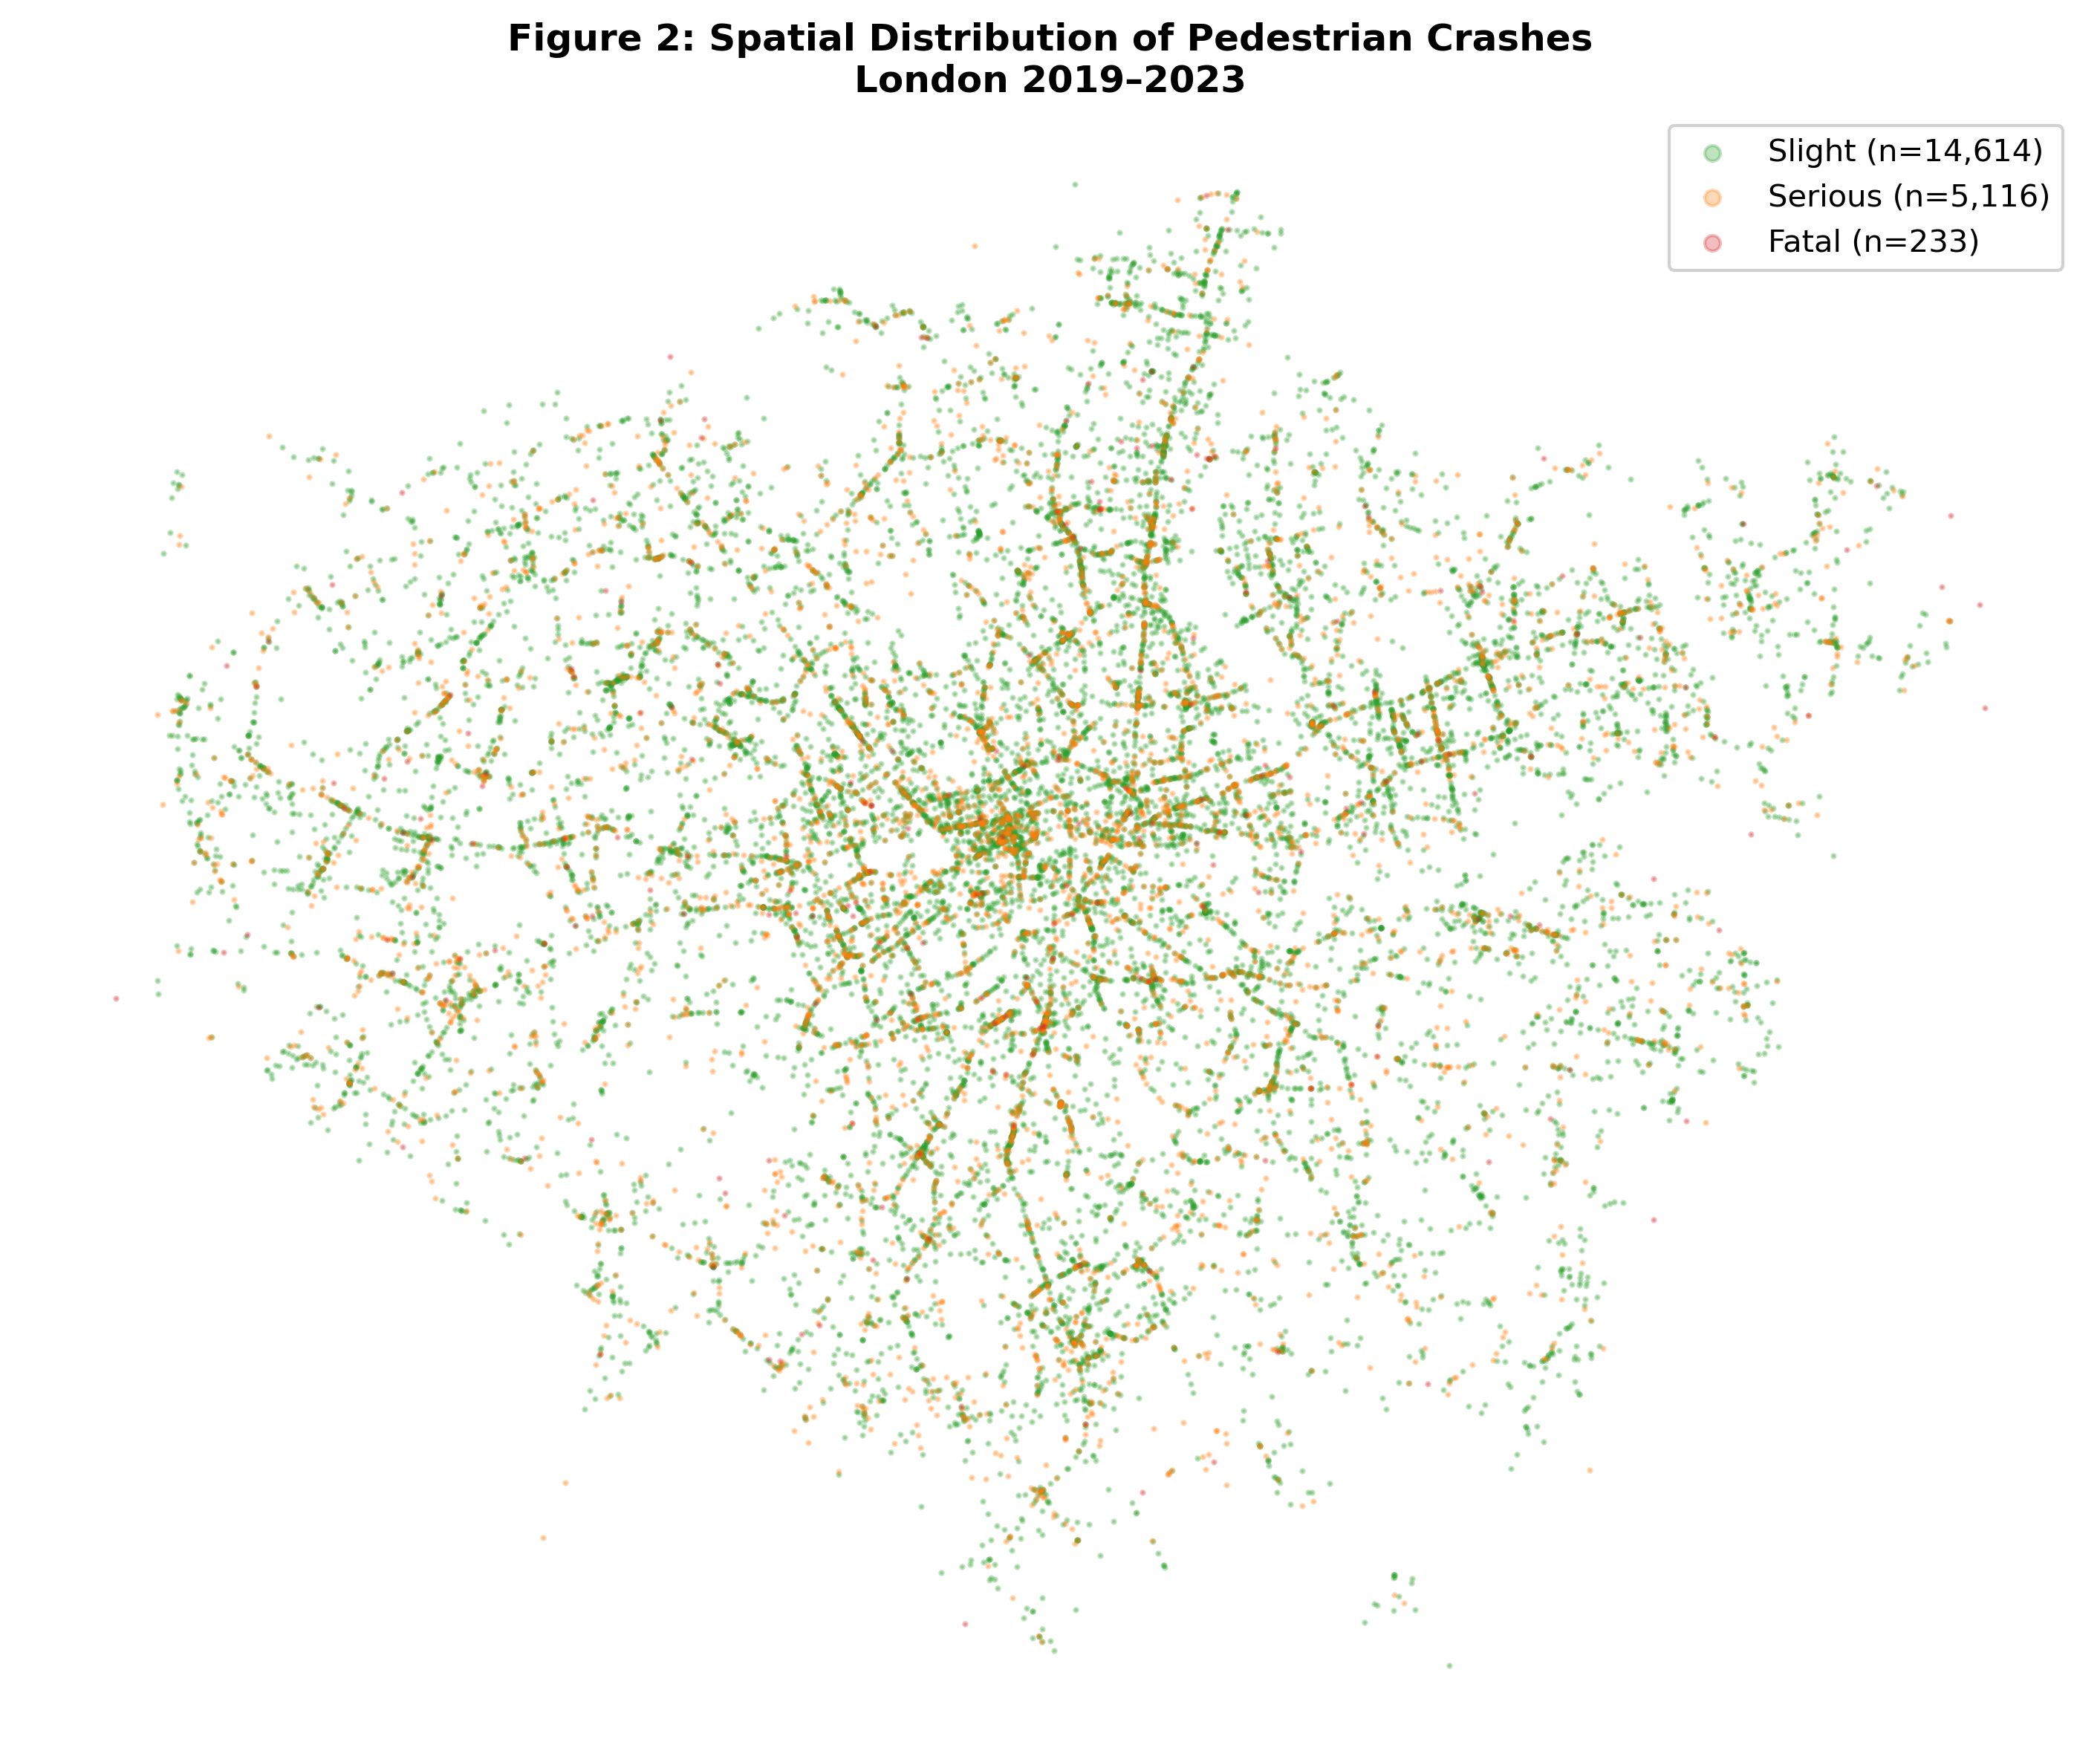

In [6]:
# ── Figure 2: Spatial Distribution of Crashes ─────────────────────────────────
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)

fig, ax = plt.subplots(figsize=(10, 8))

for severity, label, color in [
    (3, 'Slight',  COLORS['Slight']),
    (2, 'Serious', COLORS['Serious']),
    (1, 'Fatal',   COLORS['Fatal'])
]:
    subset = gdf[gdf['casualty_severity'] == severity]
    subset.plot(ax=ax, markersize=1, color=color,
                alpha=0.3, label=f'{label} (n={len(subset):,})')

ax.set_title('Figure 2: Spatial Distribution of Pedestrian Crashes\nLondon 2019–2023',
             fontsize=12, fontweight='bold')
ax.legend(markerscale=5, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../Figure/fig2_spatial_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

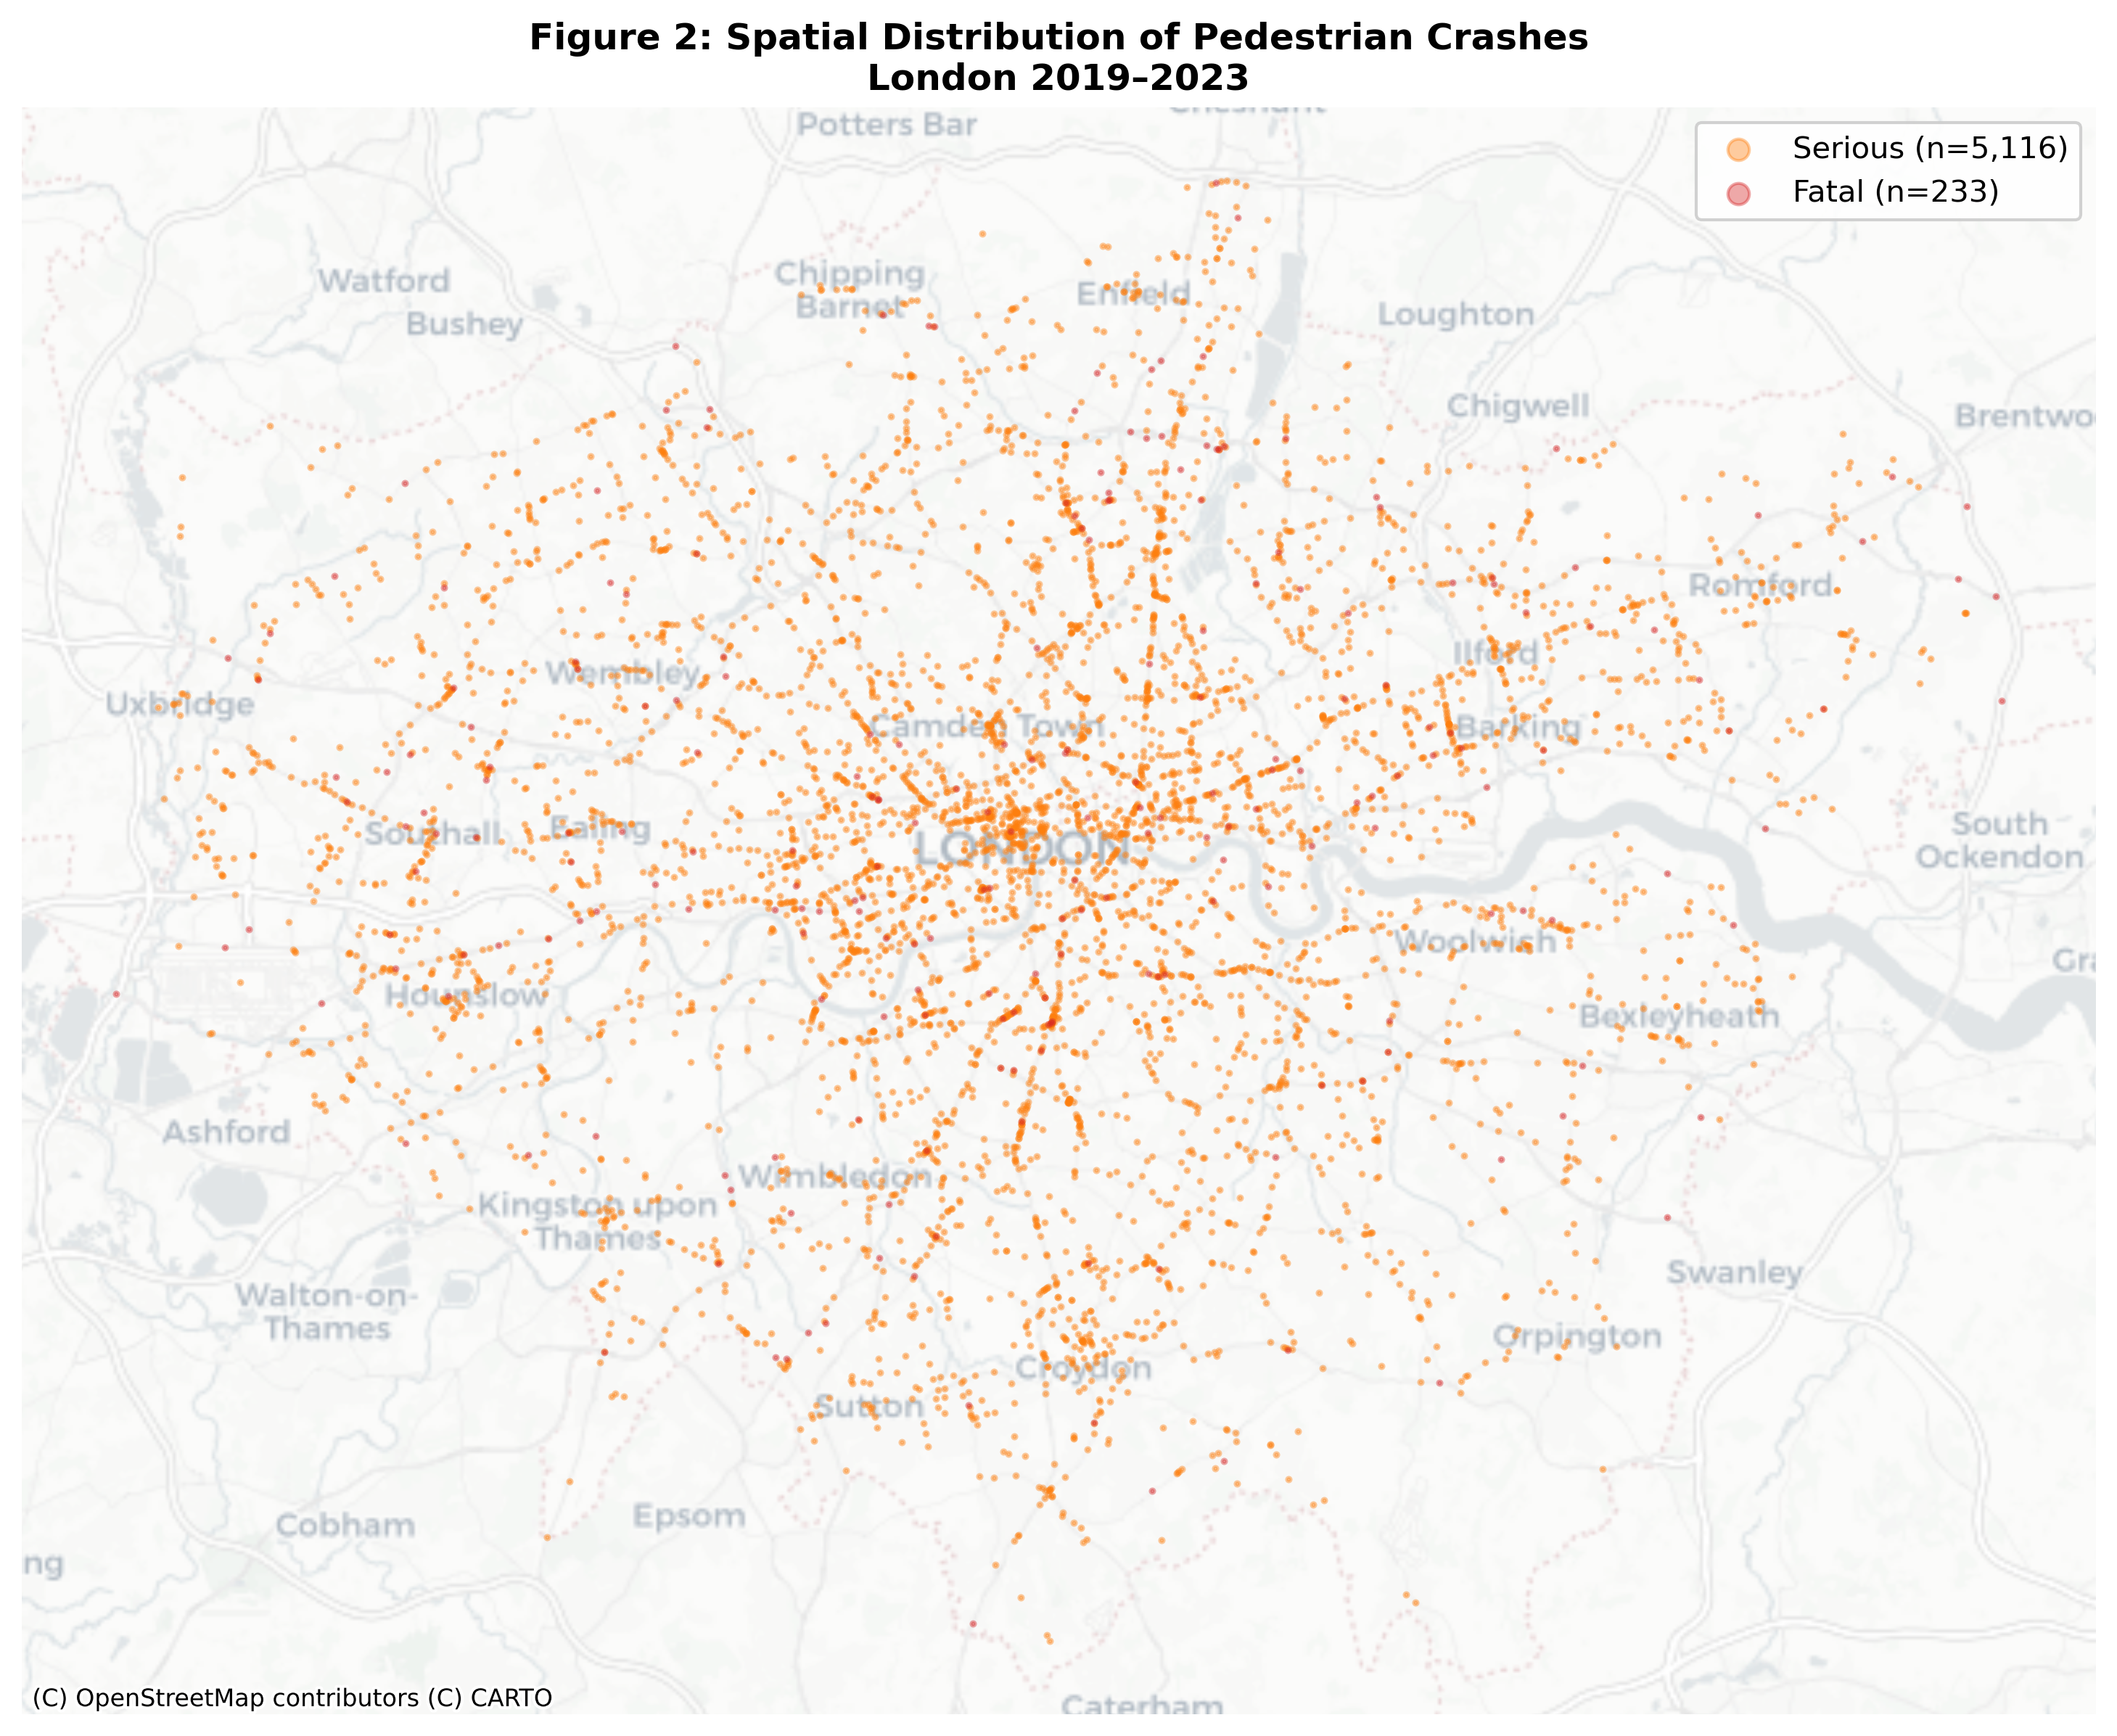

In [58]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

# ── Figure 2: Spatial Distribution of Crashes ─────────────────────────────────
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
).to_crs(epsg=3857)   # Web Mercator for basemap

fig, ax = plt.subplots(figsize=(10, 8))

for severity, label, color in [
    (2, 'Serious', COLORS['Serious']),
    (1, 'Fatal',    COLORS['Fatal'])
]:
    subset = gdf[gdf['casualty_severity'] == severity]
    subset.plot(ax=ax, markersize=2, color=color,
                alpha=0.4, label=f'{label} (n={len(subset):,})')

# Add basemap (road network visible)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, alpha=0.7)

ax.set_title('Figure 2: Spatial Distribution of Pedestrian Crashes\nLondon 2019–2023',
             fontsize=12, fontweight='bold')
ax.legend(markerscale=5, framealpha=0.9, loc='upper right')
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../Figure/fig2_spatial_distribution-KSI.png', dpi=400, bbox_inches='tight')
plt.show()

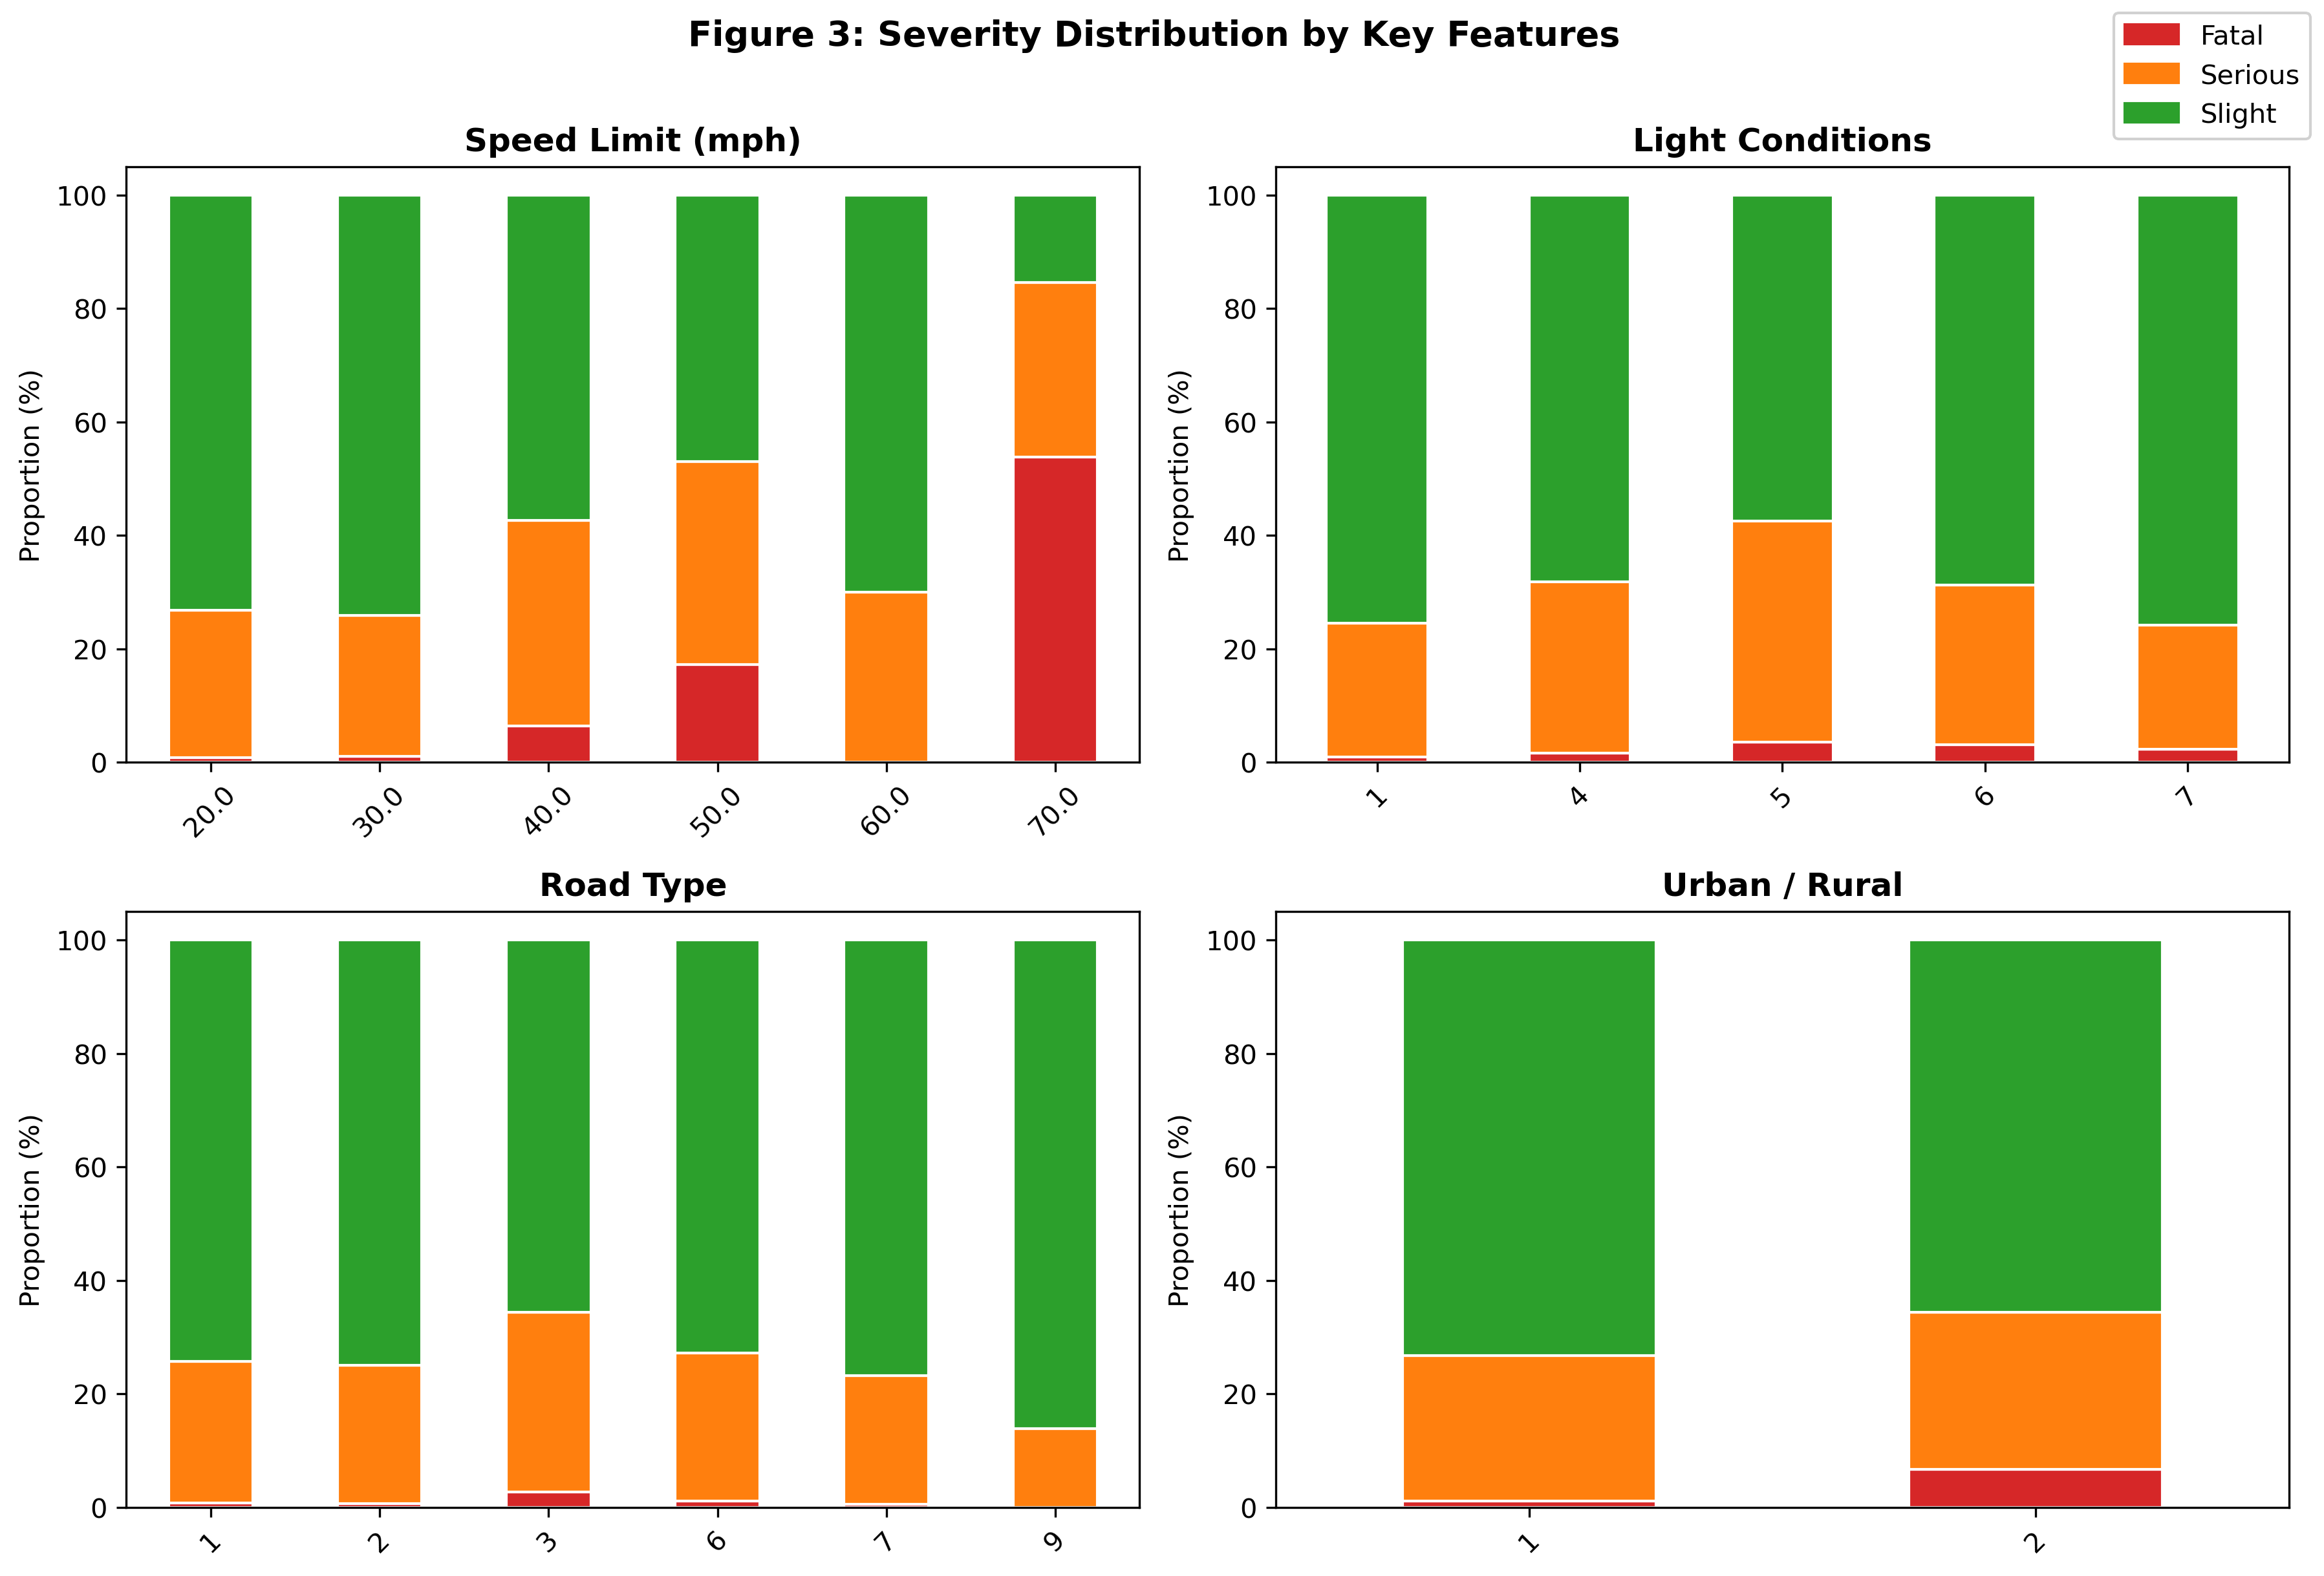

In [8]:
# ── Figure 3: Key Feature Distributions by Severity ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_vars = [
    ('speed_limit',        'Speed Limit (mph)'),
    ('light_conditions',   'Light Conditions'),
    ('road_type',          'Road Type'),
    ('urban_or_rural_area','Urban / Rural'),
]

severity_labels = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
df_plot = df.copy()
df_plot['severity_label'] = df_plot['casualty_severity'].map(severity_labels)

for ax, (col, title) in zip(axes.flat, plot_vars):
    cross = pd.crosstab(
        df_plot[col],
        df_plot['severity_label'],
        normalize='index'
    ) * 100
    cross[['Fatal', 'Serious', 'Slight']].plot(
        kind='bar', ax=ax, stacked=True,
        color=[COLORS['Fatal'], COLORS['Serious'], COLORS['Slight']],
        legend=False, edgecolor='white'
    )
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Proportion (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

handles = [plt.Rectangle((0,0),1,1, color=COLORS[s])
           for s in ['Fatal', 'Serious', 'Slight']]
fig.legend(handles, ['Fatal', 'Serious', 'Slight'],
           loc='upper right', framealpha=0.9)
fig.suptitle('Figure 3: Severity Distribution by Key Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Figure/fig3_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

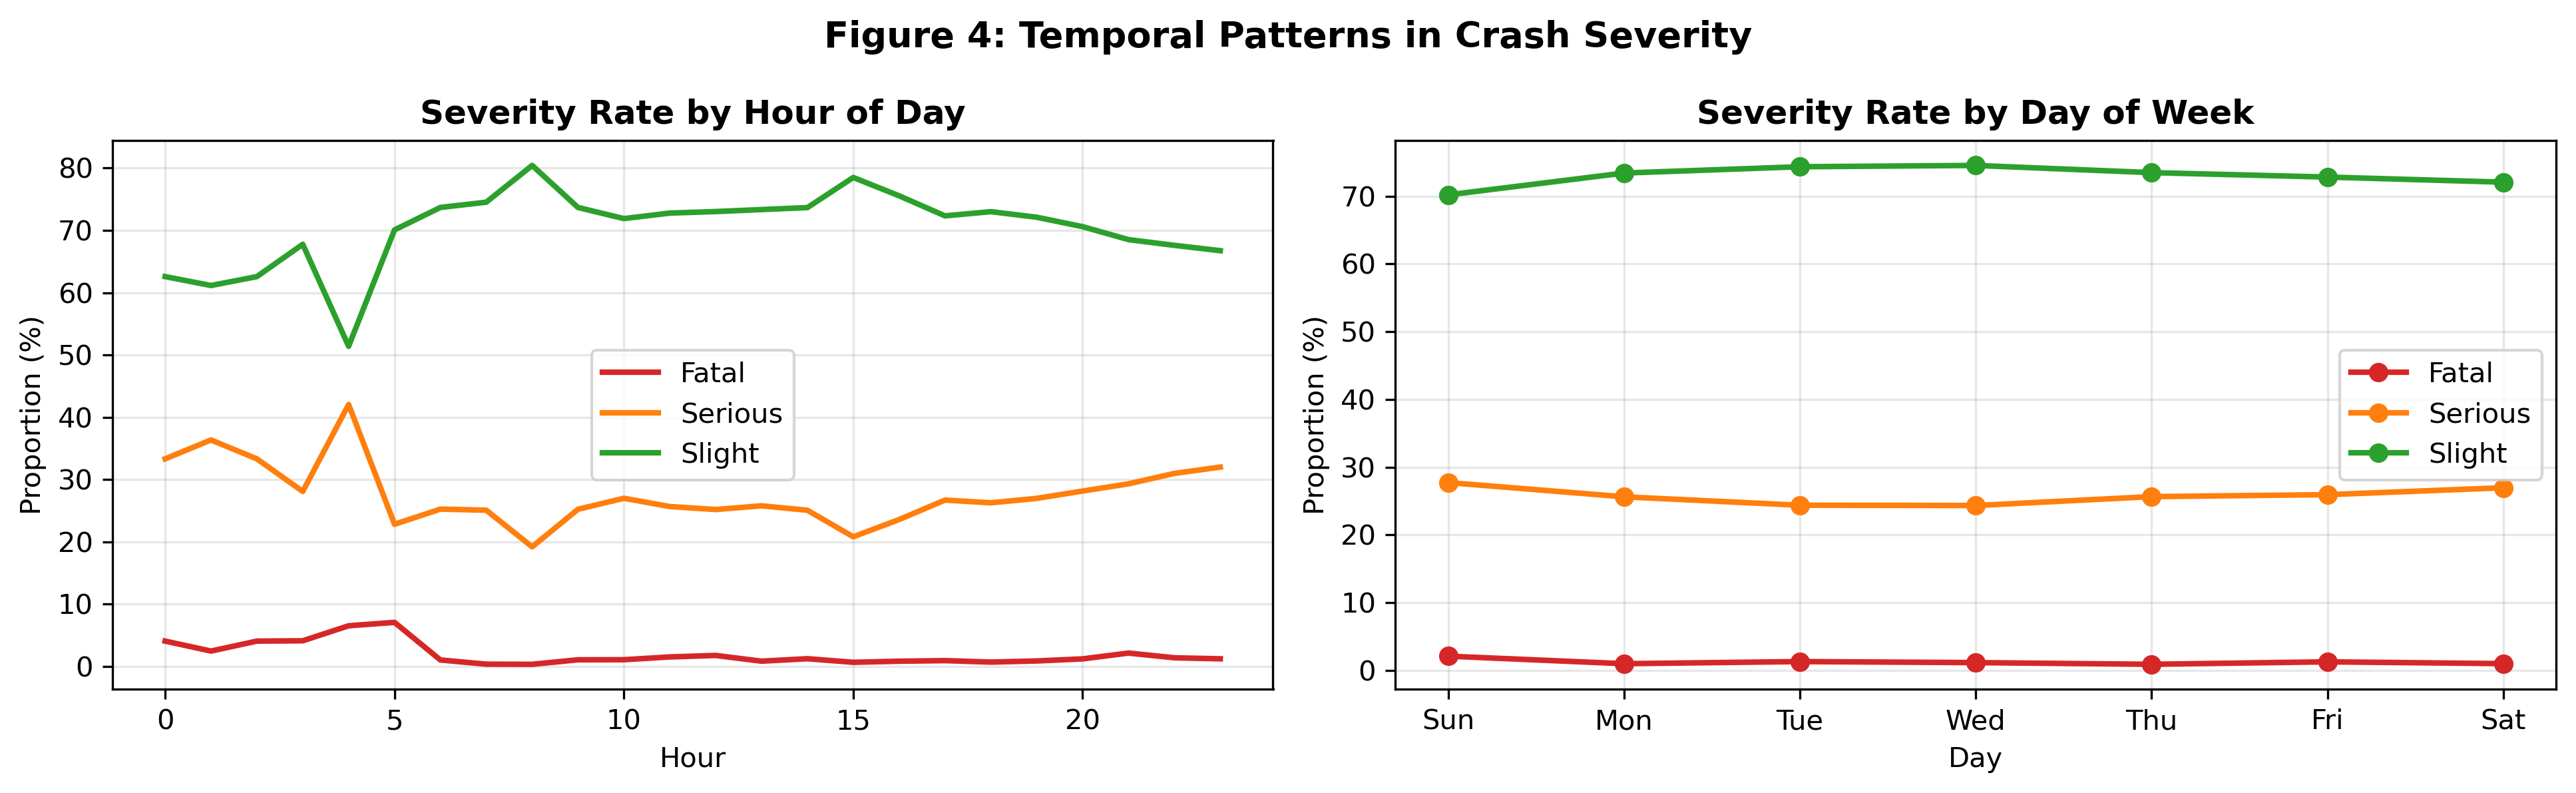

In [9]:
# ── Figure 4: Temporal Patterns ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hourly pattern
hourly = pd.crosstab(df['hour'], df['casualty_severity'], normalize='index') * 100
for sev, label, color in [(1,'Fatal',COLORS['Fatal']),
                           (2,'Serious',COLORS['Serious']),
                           (3,'Slight',COLORS['Slight'])]:
    if sev in hourly.columns:
        axes[0].plot(hourly.index, hourly[sev], label=label,
                     color=color, linewidth=2)
axes[0].set_title('Severity Rate by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Proportion (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Day of week pattern
daily = pd.crosstab(df['day_of_week'], df['casualty_severity'], normalize='index') * 100
days  = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
for sev, label, color in [(1,'Fatal',COLORS['Fatal']),
                           (2,'Serious',COLORS['Serious']),
                           (3,'Slight',COLORS['Slight'])]:
    if sev in daily.columns:
        axes[1].plot(range(len(daily)), daily[sev], label=label,
                     color=color, linewidth=2, marker='o')
axes[1].set_xticks(range(len(days)))
axes[1].set_xticklabels(days)
axes[1].set_title('Severity Rate by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Proportion (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Figure 4: Temporal Patterns in Crash Severity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../Figure/fig4_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# ── Helper Functions ──────────────────────────────────────────────────────────

def predict_with_thresholds(proba, t_fatal, t_serious):
    """Apply custom probability thresholds with Fatal > Serious priority."""
    y_pred = np.full(proba.shape[0], 3)          # default: Slight
    y_pred[proba[:, 1] >= t_serious] = 2          # Serious
    y_pred[proba[:, 0] >= t_fatal]   = 1          # Fatal (highest priority)
    return y_pred


def tune_class_weights(model, X_val, y_val):
    """Tune per-class weights applied to predict_proba before argmax."""
    y_val_proba = model.predict_proba(X_val)
    class_order = model.classes_
    
    y_default = class_order[np.argmax(y_val_proba, axis=1)]
    best_score = recall_score(y_val, y_default, average='macro')
    best_w = np.array([1.0, 1.0, 1.0])
    
    for w_f in np.arange(1, 8, 0.2):
        for w_s in np.arange(1, 4, 0.2):
            w = np.array([w_f, w_s, 1.0])
            y_pred = class_order[np.argmax(y_val_proba * w, axis=1)]
            s = recall_score(y_val, y_pred, average='macro')
            if s > best_score:
                best_score = s
                best_w = w
    return best_w, best_score


def evaluate_model(model, X_test, y_test, t_fatal, t_serious, name=''):
    """Full evaluation: default and tuned thresholds."""
    y_proba   = model.predict_proba(X_test)
    y_default = model.predict(X_test)
    y_tuned   = predict_with_thresholds(y_proba, t_fatal, t_serious)

    results = {
        'Model':           name,
        'Fatal Recall':    recall_score(y_test, y_tuned, labels=[1], average='macro'),
        'Serious Recall':  recall_score(y_test, y_tuned, labels=[2], average='macro'),
        'Slight Recall':   recall_score(y_test, y_tuned, labels=[3], average='macro'),
        'Macro F1':        f1_score(y_test, y_tuned, average='macro'),
        'G-mean':          geometric_mean_score(y_test, y_tuned, average='macro'),
        'Default G-mean':  geometric_mean_score(y_test, y_default, average='macro'),
        'Default Macro F1':f1_score(y_test, y_default, average='macro'),
    }
    return results, y_tuned, y_default


print("Helper functions defined")

Helper functions defined


---
## 6. Series A: Baseline Models (STATS19 Features Only)
*(Marking criterion: Correctness, depth, and scope — 35%)*

In [42]:
# ── Series A: Feature Matrix (no betweenness) ─────────────────────────────────
# Use X_train, X_val, X_test from Section 2.4
# (already defined above without betweenness)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=63)

param_grid_rf = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 1, 3, 5],
    'min_samples_split': [5, 8, 10],
    'class_weight':      ['balanced', {1: 50, 2: 10, 3: 1}]
}

# ── Random Forest ─────────────────────────────────────────────────────────────
gs_rf_A = GridSearchCV(
    RandomForestClassifier(random_state=63),
    param_grid_rf, cv=skf, scoring='recall_macro', n_jobs=-1, verbose=1,
)
gs_rf_A.fit(X_train, y_train)
print(f"RF-A Best params: {gs_rf_A.best_params_}")
print(f"RF-A Best recall_macro (CV): {gs_rf_A.best_score_:.3f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
RF-A Best params: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}
RF-A Best recall_macro (CV): 0.536


In [48]:
# ── Threshold Tuning: RF Series A ─────────────────────────────────────────────
# Note: tune on y_val, evaluate on y_test
# RF uses direct labels (1,2,3), no remapping needed inside tuning

t_f_rfA, t_s_rfA, gmean_val_rfA = tune_thresholds_gmean(
    gs_rf_A.best_estimator_, X_val, y_val
)
print(f"\nRF-A  Fatal threshold:   {t_f_rfA:.2f}")
print(f"RF-A  Serious threshold: {t_s_rfA:.2f}")
print(f"RF-A  G-mean on val:     {gmean_val_rfA:.3f}")

# ── Evaluate RF Series A ──────────────────────────────────────────────────────
y_rf_proba   = gs_rf_A.best_estimator_.predict_proba(X_test)
y_rf_default = gs_rf_A.best_estimator_.predict(X_test)

# Apply tuned thresholds
# RF labels: Fatal=1, Serious=2, Slight=3
y_rf_tuned = np.full(len(y_test), 3)                # default: Slight (3)
y_rf_tuned[y_rf_proba[:, 1] >= t_s_rfA] = 2         # Serious (2)
y_rf_tuned[y_rf_proba[:, 0] >= t_f_rfA] = 1         # Fatal (1)

results_rfA = {
    'Model':            'RF (Series A)',
    'Fatal Recall':     recall_score(y_test, y_rf_tuned, labels=[1], average='macro'),
    'Serious Recall':   recall_score(y_test, y_rf_tuned, labels=[2], average='macro'),
    'Slight Recall':    recall_score(y_test, y_rf_tuned, labels=[3], average='macro'),
    'Macro F1':         f1_score(y_test, y_rf_tuned, average='macro'),
    'G-mean':           geometric_mean_score(y_test, y_rf_tuned, average='macro'),
    'Default G-mean':   geometric_mean_score(y_test, y_rf_default, average='macro'),
    'Default Macro F1': f1_score(y_test, y_rf_default, average='macro'),
}

print("\n── RF Series A Results ──")
print(classification_report(y_test, y_rf_tuned,
                            target_names=['Fatal', 'Serious', 'Slight']))
print(f"G-mean (tuned):   {results_rfA['G-mean']:.3f}")
print(f"G-mean (default): {results_rfA['Default G-mean']:.3f}")


RF-A  Fatal threshold:   0.45
RF-A  Serious threshold: 0.40
RF-A  G-mean on val:     0.337

── RF Series A Results ──
              precision    recall  f1-score   support

       Fatal       0.11      0.30      0.16        47
     Serious       0.37      0.02      0.03      1023
      Slight       0.74      0.97      0.84      2923

    accuracy                           0.72      3993
   macro avg       0.41      0.43      0.35      3993
weighted avg       0.64      0.72      0.63      3993

G-mean (tuned):   0.540
G-mean (default): 0.605


In [34]:
# ── XGBoost Series A ──────────────────────────────────────────────────────────
param_grid_xgb = {
    'n_estimators':  [100, 200],
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

# Map y to 0-indexed for XGBoost: Fatal=0, Serious=1, Slight=2
y_train_xgb = y_train - 1
y_val_xgb   = y_val   - 1
y_test_xgb  = y_test  - 1

gs_xgb_A = GridSearchCV(
    XGBClassifier(random_state=24, eval_metric='mlogloss',
                  device='cuda'),  
    param_grid_xgb, cv=skf, scoring='recall_macro', n_jobs=1, verbose=1
)
gs_xgb_A.fit(X_train, y_train_xgb)
print(f"XGB-A Best params: {gs_xgb_A.best_params_}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
XGB-A Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}


In [28]:
# ── Threshold Tuning: XGBoost Series A ───────────────────────────────────────
# Note: tune on y_val_xgb (0-indexed), evaluate on y_test_xgb (0-indexed)
# Then remap back to 1,2,3 for consistent reporting with RF results

def tune_thresholds_gmean_xgb(model, X_val, y_val_xgb):
    """Same as tune_thresholds_gmean but for 0-indexed XGBoost labels."""
    y_val_proba = model.predict_proba(X_val)
    thresholds  = np.arange(0.05, 0.60, 0.05)
    best_t_f, best_t_s, best_gmean = 0.5, 0.5, 0.0

    for t_f in thresholds:
        for t_s in thresholds:
            # 0-indexed: Fatal=0, Serious=1, Slight=2
            y_pred_temp = np.full(len(y_val_xgb), 2)   # default: Slight (2)
            y_pred_temp[y_val_proba[:, 1] >= t_s] = 1  # Serious (1)
            y_pred_temp[y_val_proba[:, 0] >= t_f] = 0  # Fatal (0)
            
            g = geometric_mean_score(y_val_xgb, y_pred_temp, average='macro')
            if g > best_gmean:
                best_gmean = g
                best_t_f, best_t_s = t_f, t_s

    return best_t_f, best_t_s, best_gmean


t_f_xgbA, t_s_xgbA, gmean_val_xgbA = tune_thresholds_gmean_xgb(
    gs_xgb_A.best_estimator_, X_val, y_val_xgb
)
print(f"\nXGB-A  Fatal threshold:   {t_f_xgbA:.2f}")
print(f"XGB-A  Serious threshold: {t_s_xgbA:.2f}")
print(f"XGB-A  G-mean on val:     {gmean_val_xgbA:.3f}")

# ── Evaluate XGBoost Series A ─────────────────────────────────────────────────
y_xgb_proba   = gs_xgb_A.best_estimator_.predict_proba(X_test)
y_xgb_default = gs_xgb_A.best_estimator_.predict(X_test) + 1  # remap to 1,2,3

# Apply tuned thresholds
y_xgb_tuned = np.full(len(y_test_xgb), 2)            # default: Slight (2)
y_xgb_tuned[y_xgb_proba[:, 1] >= t_s_xgbA] = 1      # Serious (1)
y_xgb_tuned[y_xgb_proba[:, 0] >= t_f_xgbA] = 0      # Fatal (0)
y_xgb_tuned = y_xgb_tuned + 1                        # remap to 1,2,3 for reporting

results_xgbA = {
    'Model':            'XGBoost (Series A)',
    'Fatal Recall':     recall_score(y_test, y_xgb_tuned, labels=[1], average='macro'),
    'Serious Recall':   recall_score(y_test, y_xgb_tuned, labels=[2], average='macro'),
    'Slight Recall':    recall_score(y_test, y_xgb_tuned, labels=[3], average='macro'),
    'Macro F1':         f1_score(y_test, y_xgb_tuned, average='macro'),
    'G-mean':           geometric_mean_score(y_test, y_xgb_tuned, average='macro'),
    'Default G-mean':   geometric_mean_score(y_test, y_xgb_default, average='macro'),
    'Default Macro F1': f1_score(y_test, y_xgb_default, average='macro'),
}

print("\n── XGBoost Series A Results ──")
print(classification_report(y_test, y_xgb_tuned,
                             target_names=['Fatal', 'Serious', 'Slight']))
print(f"G-mean (tuned):   {results_xgbA['G-mean']:.3f}")
print(f"G-mean (default): {results_xgbA['Default G-mean']:.3f}")


XGB-A  Fatal threshold:   0.05
XGB-A  Serious threshold: 0.25
XGB-A  G-mean on val:     0.596

── XGBoost Series A Results ──
              precision    recall  f1-score   support

       Fatal       0.13      0.36      0.19        47
     Serious       0.31      0.54      0.40      1023
      Slight       0.80      0.58      0.67      2923

    accuracy                           0.56      3993
   macro avg       0.41      0.49      0.42      3993
weighted avg       0.66      0.56      0.59      3993

G-mean (tuned):   0.595
G-mean (default): 0.494


In [53]:
import shap

# ── SHAP: XGBoost Series A ────────────────────────────────────────────────────
booster = gs_xgb_A.best_estimator_.get_booster()
booster.set_param({'device': 'cpu'})   # SHAP 在 CPU 上跑，避免 CUDA 冲突

explainer   = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=20)

# Beeswarm
shap.summary_plot(shap_values, X_test, max_display=20)

# Top feature dependence
top_feature = pd.DataFrame({
    'feature': X_test.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False).iloc[0]['feature']

shap.dependence_plot(top_feature, shap_values, X_test)

ValueError: could not convert string to float: '[-2.4130607E0,6.818161E-1,1.7312447E0]'